In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from beliefppg import infer_hr
import os

from sklearn.metrics import mean_absolute_error

In [3]:
BASE_PATH = Path("../../data/processed/dalia")
PATIENTS = [f"S{i}" for i in range(1, 16)]  # S1 to S15


def load_bvp_acc_hr(patient: str):
    patient_path = os.path.join(BASE_PATH, patient)
    bvp = pd.read_csv(os.path.join(patient_path, "wrist/wrist_BVP.csv"))
    acc = pd.read_csv(os.path.join(patient_path, "wrist/wrist_ACC.csv"))
    label = pd.read_csv(os.path.join(patient_path, "label.csv"))

    return bvp, acc, label

In [4]:
def retrieve_pred_hr(p: str):
    bvp_df, acc_df, hr_df = load_bvp_acc_hr(p)

    print(f"{p} - BVP shape: {bvp_df.shape}, ACC shape: {acc_df.shape}, HR shape: {hr_df.shape}")

    # 1. Convert DataFrames to NumPy arrays
    bvp_arr = bvp_df.values
    acc_arr = acc_df.values

    # 2. Run inference with the correct 32 Hz ACC frequency
    pred_hr, idx = infer_hr(
        ppg=bvp_arr,
        ppg_freq=64,
        acc=acc_arr,
        acc_freq=32
    )

    print(f"Predicted HR array shape: {pred_hr.shape}")

    # 1. Convert the 'idx' (which is in 64Hz sample numbers) to seconds
    pred_time_sec = idx / 64.0

    # 2. Create a time array for your ground truth HR
    # (4603 values, spaced by 2 seconds. The first 8-second window centers at 4 seconds)
    gt_time_sec = np.arange(len(hr_df)) * 2.0 + 4.0

    # 3. Interpolate the 4597 predictions to match the 4603 ground truth timestamps
    aligned_pred_hr = np.interp(
        gt_time_sec,       # The x-coordinates we want to evaluate at
        pred_time_sec,     # The x-coordinates we have
        pred_hr            # The y-coordinates we have
    )

    # 4. Reshape hr_df to a 1D array if it isn't already
    gt_hr_1d = hr_df.values.flatten()

    # 5. Calculate the final error!
    mae = mean_absolute_error(gt_hr_1d, aligned_pred_hr)

    print(f"Final aligned prediction shape: {aligned_pred_hr.shape}")
    print(f"Ground truth shape: {gt_hr_1d.shape}")
    print(f"Mean Absolute Error (MAE): {mae:.2f} BPM")

    return pred_hr, idx, mae, hr_df



In [5]:
patient = "S1"

hr, idx, mae, labels = retrieve_pred_hr(patient)

print(f"{patient} - HR shape: {hr.shape}")
print(f"Total beats {len(idx)}")

S1 - BVP shape: (589568, 1), ACC shape: (294784, 3), HR shape: (4603, 1)


37/37 [==============================] - 6s 118ms/step
Predicted HR array shape: (4597,)
Final aligned prediction shape: (4603,)
Ground truth shape: (4603,)
Mean Absolute Error (MAE): 4.21 BPM
S1 - HR shape: (4597,)
Total beats 4597


In [6]:
print(idx)

differences = np.diff(idx)

differences / 64

[    64    192    320 ... 588096 588224 588352]


array([2., 2., 2., ..., 2., 2., 2.], shape=(4596,))

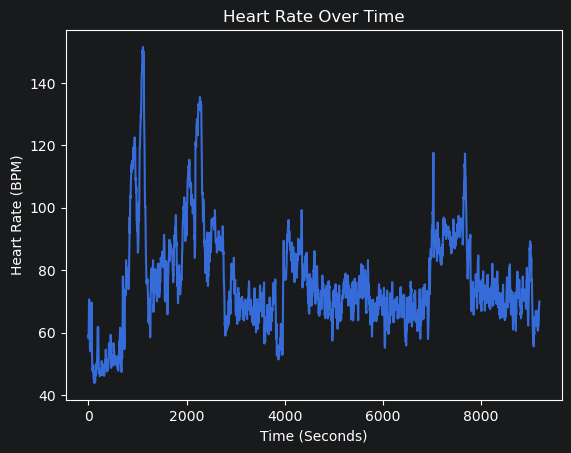

In [7]:
import matplotlib.pyplot as plt

time_in_seconds = idx / 64
plt.plot(time_in_seconds, hr)
plt.xlabel("Time (Seconds)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over Time")
plt.show()

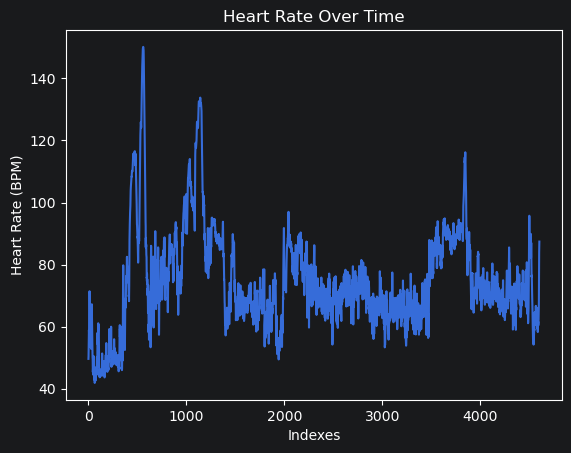

In [8]:
plt.plot(labels.index, labels)
plt.xlabel("Indexes")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over Time")
plt.show()

In [9]:
print(hr.shape)
print(labels.shape)

(4597,)
(4603, 1)


In [10]:
# 1. Safely extract and flatten the Pandas DataFrame into a 1D NumPy array
labels_flat = labels.to_numpy().flatten()

# 2. Calculate how many extra labels we have
diff = len(labels_flat) - len(hr) # Should be 6

# 3. Split the difference symmetrically
crop_start = diff // 2
crop_end = diff - crop_start

# 4. Slice the labels array to drop the edges
aligned_labels = labels_flat[crop_start : -crop_end]

# 5. Verify the shapes perfectly match
print("HR Shape:", hr.shape)
print("Labels Shape:", aligned_labels.shape)

# 6. Calculate your Mean Absolute Error!
error = np.abs(hr - aligned_labels)
mae = np.mean(error)

print(f"Mean Absolute Error: {mae:.2f} BPM")

HR Shape: (4597,)
Labels Shape: (4597,)
Mean Absolute Error: 2.92 BPM


In [12]:
successive_differences = np.abs(np.diff(hr))
mean_volatility = float(np.mean(successive_differences))

mean_volatility

1.208262324333191

In [13]:
hr.shape

(4597,)